In [1]:
# Imports
import os
import cv2

from modules.inference.model import Detector
from modules.inference.nms import NMS
from modules.utils.metrics import match_detections, calculate_precision_recall_curve, calculate_map_x_point_interpolated

print('DONE')

DONE


In [13]:
# Match jpg files to txt files
dataset_path = 'storage/logistics/'
files = os.listdir(dataset_path)

image_key = {}
for file in files:
    suffix = file[-4:]
    if suffix == '.jpg':
        image_key[file] = file[:-4] + '.txt'

# Get GT data from txt files
gt_boxes = []
gt_classes = []
sizes = []

for jpg, txt in image_key.items():

    # Get frame dimmensions
    frame = cv2.imread(dataset_path + jpg)
    sizes.append(frame.shape[:2])

    # Read GT data 
    with open(dataset_path + txt, 'r') as f:
        b_list = []
        c_list = []
        for line in f:
            data = [float(n) for n in line.strip('\n').split(' ')]
            b_list.append(data[1:])
            c_list.append(int(data[0]))

    # Save GT data
    gt_boxes.append(b_list)
    gt_classes.append(c_list)


In [14]:
# Gather distribution of classes present in dataset from ground truth info
pre_filter_buckets = {i:0 for i in range(20)}

for cls_scores in gt_classes:
    for cls in cls_scores:
        pre_filter_buckets[cls] += 1

pre_filter_buckets

{0: 283,
 1: 1379,
 2: 4995,
 3: 2793,
 4: 1103,
 5: 318,
 6: 256,
 7: 2170,
 8: 277,
 9: 359,
 10: 6368,
 11: 369,
 12: 720,
 13: 1260,
 14: 1495,
 15: 506,
 16: 1193,
 17: 782,
 18: 765,
 19: 9330}

In [22]:
image[:-4] + '.txt'

'2014-mitsubishi-fuso-fe160-14-feet-b_jpg.rf.5736bf50428693a213498f54dedace62.txt'

In [ ]:
# 'techtrack-Sean090900/techtrack/storage/sampled_dataset_5000'
# Randomly remove images until 5000 remain
import random
import shutil

images = list(image_key.keys())
random.shuffle(images)

destination_path = 'storage/sampled_dataset_5000'

count = 0
for image in images:

    if count == 5000:
        break

    # Copy JPG
    shutil.copy(dataset_path + image, destination_path)
    # Copy TXT
    shutil.copy(dataset_path + image[:-4] + '.txt', destination_path)

    count += 1 


In [25]:
# Match jpg files to txt files
dataset_path = 'storage/sampled_dataset_5000/'
files = os.listdir(dataset_path)

image_key = {}
for file in files:
    suffix = file[-4:]
    if suffix == '.jpg':
        image_key[file] = file[:-4] + '.txt'

# Get GT data from txt files
gt_boxes = []
gt_classes = []
sizes = []

for jpg, txt in image_key.items():

    # Get frame dimmensions
    frame = cv2.imread(dataset_path + jpg)
    sizes.append(frame.shape[:2])

    # Read GT data 
    with open(dataset_path + txt, 'r') as f:
        b_list = []
        c_list = []
        for line in f:
            data = [float(n) for n in line.strip('\n').split(' ')]
            b_list.append(data[1:])
            c_list.append(int(data[0]))

    # Save GT data
    gt_boxes.append(b_list)
    gt_classes.append(c_list)


In [26]:
# Gather distribution of classes present in dataset from ground truth info
post_filter_buckets = {i:0 for i in range(20)}

for cls_scores in gt_classes:
    for cls in cls_scores:
        post_filter_buckets[cls] += 1

post_filter_buckets

{0: 168,
 1: 650,
 2: 2667,
 3: 1444,
 4: 577,
 5: 162,
 6: 125,
 7: 1158,
 8: 151,
 9: 183,
 10: 3446,
 11: 187,
 12: 331,
 13: 624,
 14: 742,
 15: 272,
 16: 640,
 17: 424,
 18: 395,
 19: 5036}

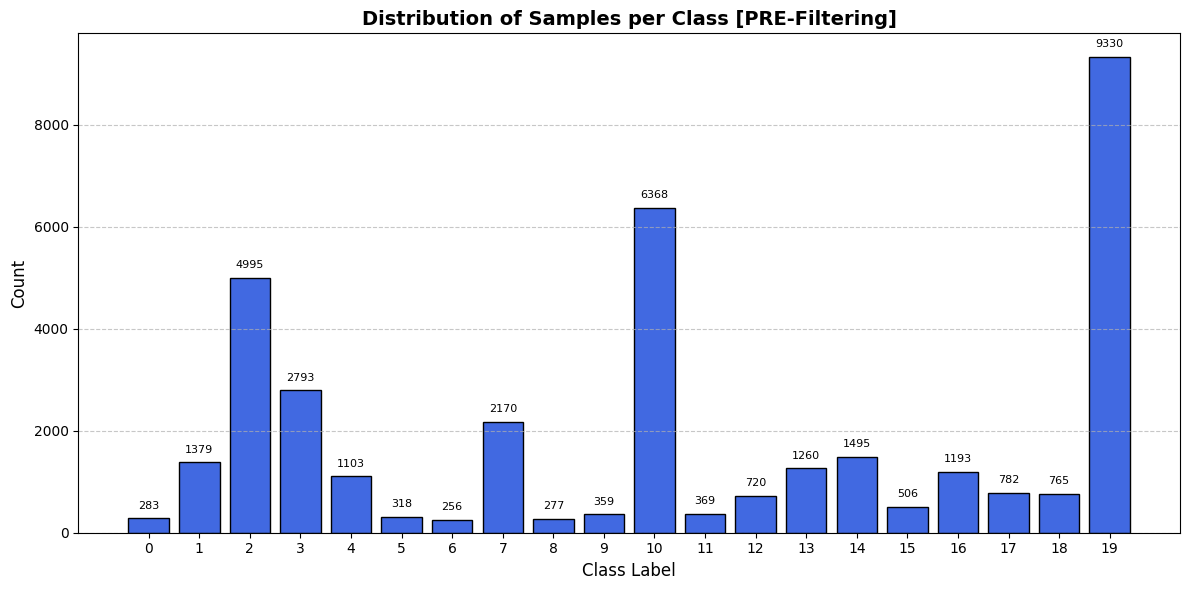

In [30]:
import matplotlib.pyplot as plt

# Extract class labels and counts
classes = list(pre_filter_buckets.keys())
counts = list(pre_filter_buckets.values())

# Create the bar plot
plt.figure(figsize=(12, 6))
plt.bar(classes, counts, color='royalblue', edgecolor='black')

# Add labels, title, and grid
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Samples per Class [PRE-Filtering]', fontsize=14, weight='bold')
plt.xticks(classes)  # show all class labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: annotate bars with counts
for i, count in enumerate(counts):
    plt.text(classes[i], count + 150, str(count), ha='center', va='bottom', fontsize=8)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

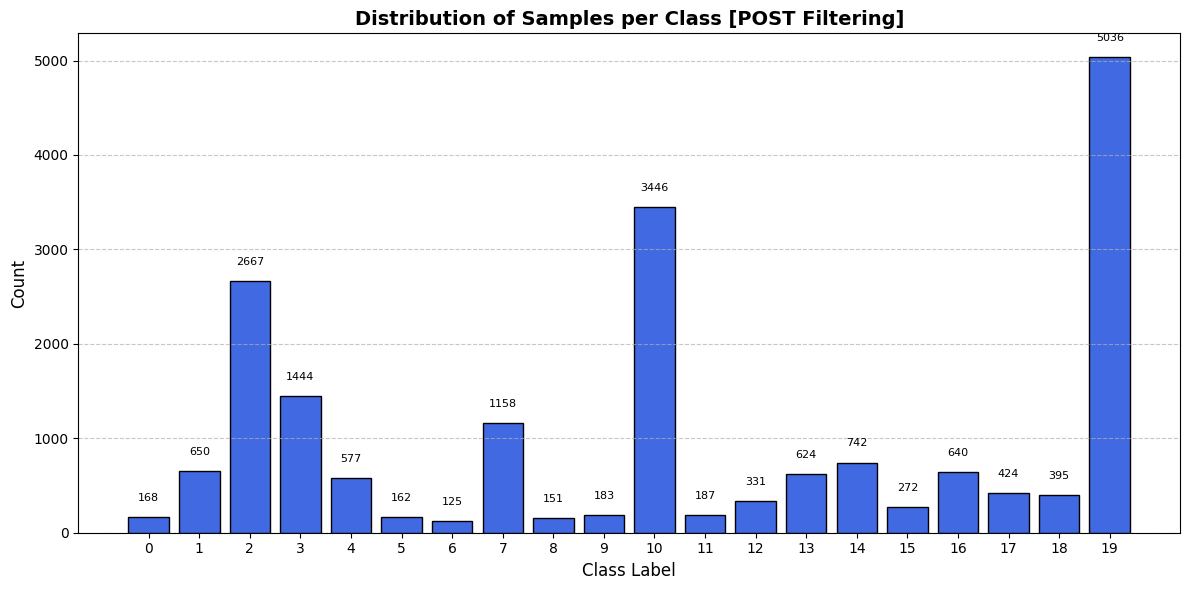

In [32]:
import matplotlib.pyplot as plt

# Extract class labels and counts
classes = list(post_filter_buckets.keys())
counts = list(post_filter_buckets.values())

# Create the bar plot
plt.figure(figsize=(12, 6))
plt.bar(classes, counts, color='royalblue', edgecolor='black')

# Add labels, title, and grid
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Samples per Class [POST Filtering]', fontsize=14, weight='bold')
plt.xticks(classes)  # show all class labels
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: annotate bars with counts
for i, count in enumerate(counts):
    plt.text(classes[i], count + 150, str(count), ha='center', va='bottom', fontsize=8)

# Optimize layout
plt.tight_layout()

# Display the plot
plt.show()

In [31]:
plt.savefig(f"storage/filtering_charts/pre-filter-distribution.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>